# Test — evaluation on MIT1003

Evaluates a trained checkpoint on **MIT1003**, our held-out test set.
Since models are trained on SALICON, this is a **cross-dataset** evaluation: it measures generalization to real eye-tracking data.

- Loads the newest `checkpoints/best_model_<experiment>_*.pth` (or set `CKPT_PATH` manually).
- Computes the metrics registered in `config.py` (PCC, JSS, MSE) with the same `validate()` used during training.
- Produces the qualitative figure (image | prediction | ground truth) for the report.
  Sample indices are fixed so the same figure is comparable across models.

In [1]:
import os, glob
import torch
import numpy as np
import matplotlib.pyplot as plt

from config import get_config
from models import build_model
from losses import build_loss
from metrics import build_metrics
from data import create_mit_test_loader
from train import validate

#  settings 
EXPERIMENT = "multiscale_skip"   # baseline or multiscale
CKPT_PATH = None          # None -> newest matching checkpoint in checkpoints/
SAVE_PLOTS = True
PLOT_DIR = "plots"

config = get_config(EXPERIMENT)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

if CKPT_PATH is None:
    ckpts = sorted(glob.glob(f"checkpoints/best_model_{EXPERIMENT}_*.pth"), key=os.path.getmtime)
    assert ckpts, f"No checkpoint found for '{EXPERIMENT}' in checkpoints/"
    CKPT_PATH = ckpts[-1]

model = build_model(config.model).to(device)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()
print(f"Loaded checkpoint: {CKPT_PATH}")

SaliencyDataset class defined.

--- Data Preparation Complete ---
Using device: cuda
Loaded checkpoint: checkpoints/best_model_multiscale_skip_20260712_120737.pth


In [2]:
#  quantitative evaluation on MIT1003 
test_loader = create_mit_test_loader(config)
criterion = build_loss(config.loss).to(device)
metrics = build_metrics(config.metrics)

results = validate(model, test_loader, criterion, metrics, device)
results["test_loss"] = results.pop("val_loss")  # rename: this is the test set

print(f"\n--- Test results on MIT1003 ({len(test_loader.dataset)} images) | {EXPERIMENT} ---")
for k, v in results.items():
    print(f"{k:10s}: {v:.4f}")

/home/gica2600/miniconda3/envs/nndl_saliency/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Validating:   0%|          | 0/32 [00:00<?, ?it/s]/home/gica2600/miniconda3/envs/nndl_saliency/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid p


--- Test results on MIT1003 (1003 images) | multiscale_skip ---
PCC       : 0.6284
JSS       : 0.7568
MSE       : 0.0162
test_loss : 0.0162


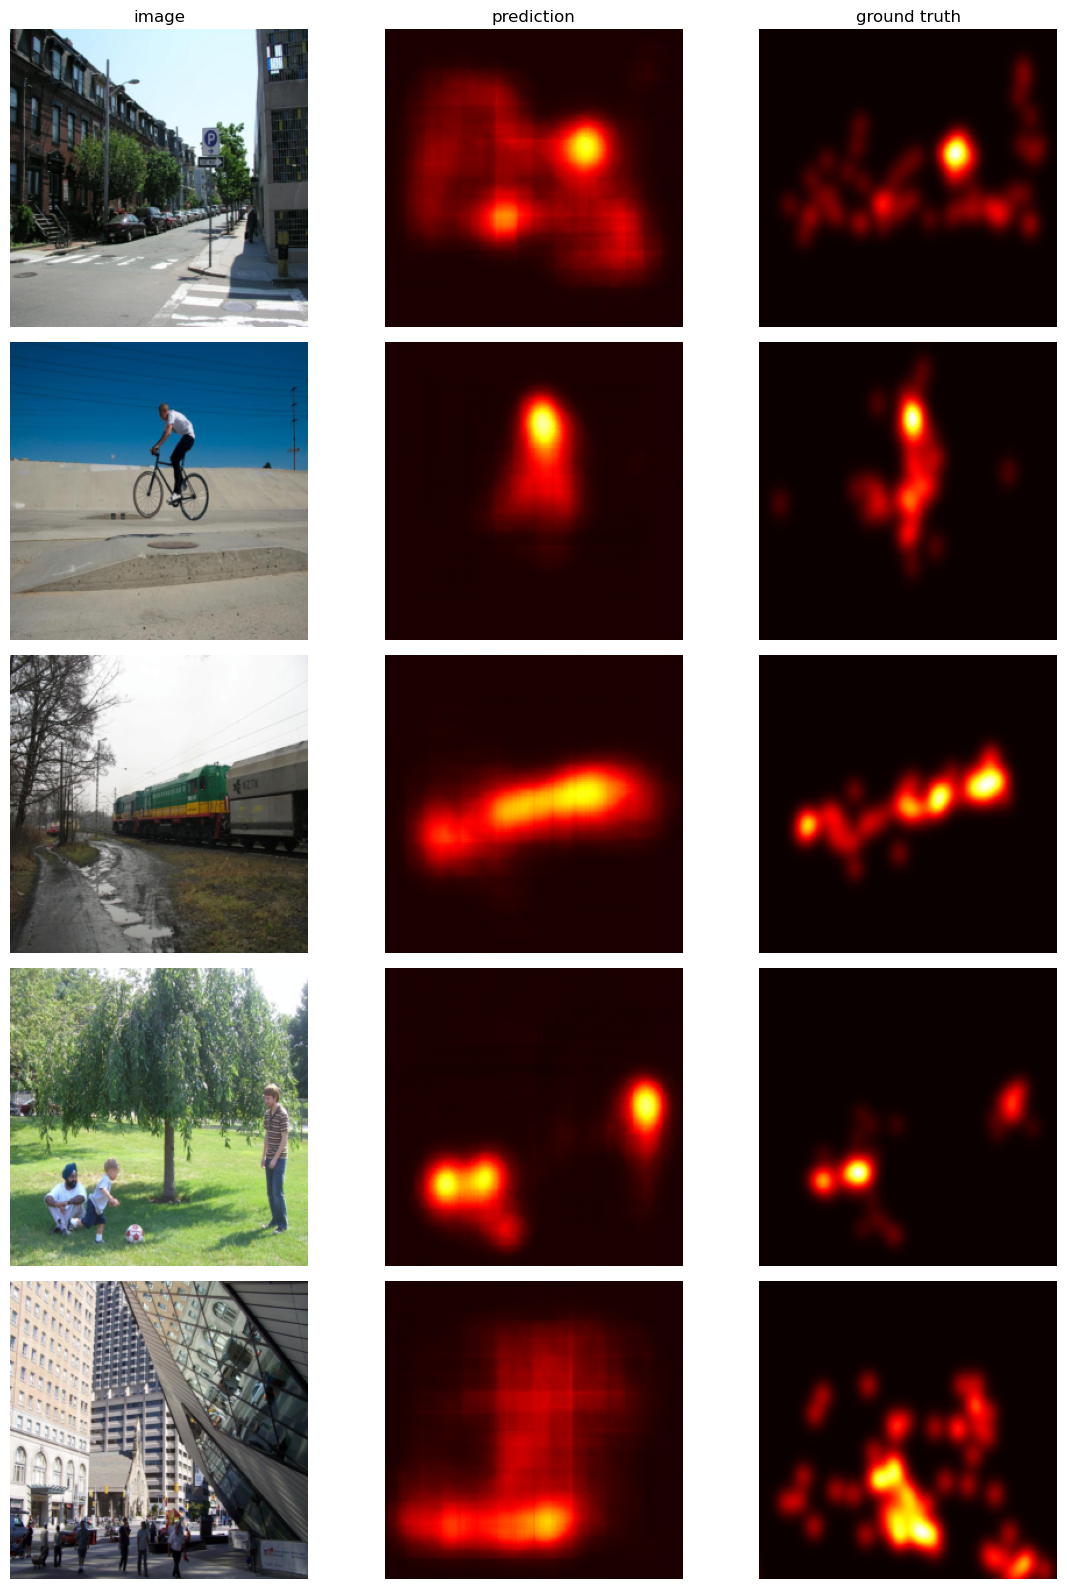

In [3]:
#  qualitative results: image | prediction | ground truth 
MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])
sample_idxs = [0, 150, 300, 450, 600]   # fixed -> comparable across models

ds = test_loader.dataset
fig, axes = plt.subplots(len(sample_idxs), 3, figsize=(12, 3.2 * len(sample_idxs)))

for row, idx in enumerate(sample_idxs):
    image, gt = ds[idx]
    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device)).squeeze().cpu().numpy()
    img_np = np.clip(image.permute(1, 2, 0).numpy() * STD + MEAN, 0, 1)  # undo ImageNet normalization

    axes[row, 0].imshow(img_np)
    axes[row, 1].imshow(pred, cmap="hot", vmin=0, vmax=1)
    axes[row, 2].imshow(gt.squeeze().numpy(), cmap="hot", vmin=0, vmax=1)
    for ax in axes[row]:
        ax.axis("off")

for col, title in enumerate(["image", "prediction", "ground truth"]):
    axes[0, col].set_title(title)

plt.tight_layout()
if SAVE_PLOTS:
    os.makedirs(PLOT_DIR, exist_ok=True)
    plt.savefig(os.path.join(PLOT_DIR, f"test_{EXPERIMENT}_qualitative.png"), dpi=150, bbox_inches="tight")
plt.show()

In [4]:
#save ALL prediction maps to output/<model_name>/
from PIL import Image
from tqdm import tqdm

OUT_DIR = os.path.join("output", config.model.name)
os.makedirs(OUT_DIR, exist_ok=True)

ds = test_loader.dataset
i = 0
with torch.no_grad():
    for images, _ in tqdm(test_loader, desc="Saving predictions"):
        preds = model(images.to(device)).cpu().numpy()  # (B,1,256,256)
        for p in preds:
            fname = ds.image_files[i]  # loader has shuffle=False -> order matches
            base = os.path.splitext(fname)[0]
            # resize back to the original stimulus size -> comparable with
            # ALLFIXATIONMAPS files and usable by external benchmark code
            orig_size = Image.open(os.path.join(ds.image_dir, fname)).size  # (W,H)
            pm = Image.fromarray((p[0] * 255).astype(np.uint8), mode="L")
            pm = pm.resize(orig_size, Image.BILINEAR)
            pm.save(os.path.join(OUT_DIR, base + ".png"))
            i += 1

print(f"Saved {i} prediction maps to {OUT_DIR}/")

Saving predictions: 100%|██████████| 32/32 [00:20<00:00,  1.57it/s]

Saved 1003 prediction maps to output/MultiScaleSkipCNN/
